In [1]:
import requests
import pandas as pd
from datetime import datetime, timezone
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap
from matplotlib.patches import Patch
import matplotlib.dates as mdates
import ast
import folium
from folium.plugins import MarkerCluster
import reverse_geocoder as rg
import re
import pycountry
import os
import numpy as np
import geopandas as gpd
import fiona
import sys
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
import ruptures as rpt
from haversine import haversine
import functions as own
from timezonefinder import TimezoneFinder
import zoneinfo
from itertools import product
from scipy.stats import spearmanr
import seaborn as sns

Now, we want to know whether cantons actually experienced real adoption of the CrowdWater app. For this, we look whether, in each canton, there was/were (a) time period(s) of at least 3 months with at least 10 observations per month.

First the code to identify sustained adoption phases with minimum number of observations and minimum number of months as thresholds

In [ ]:
def sustained_adoption(df, min_obs, min_months, min_users):

    df = df.copy()
    
    # 1. monthly aggregation
    if not isinstance(df["year_month"].dtype, pd.PeriodDtype):
        df["year_month"] = pd.to_datetime(df["year_month"]).dt.to_period("M")
    
    monthly = (
        df.groupby(["Region", "year_month"])
          .agg(
              monthly_obs=("created_by", "size"),
              monthly_users=("created_by", "nunique")
          )
          .reset_index()
    )
    
    results = []
    
    # 2. analysis per canton
    for region, d in monthly.groupby("Region"):
        
        d = d.sort_values("year_month").copy()
        
        # add missing months
        full_index = pd.period_range(
            d["year_month"].min(),
            d["year_month"].max(),
            freq="M"
        )
        
        d = (
            d.set_index("year_month")[["monthly_obs", "monthly_users"]]
             .reindex(full_index, fill_value=0)
        )
        d.index.name = "year_month"
        d = d.reset_index()
        
        # 3. test threshold
        d["above_threshold"] = (d["monthly_obs"] >= min_obs) & (d["monthly_users"] >= min_users)
        
        # 4. identify consecutive phases
        d["group"] = (d["above_threshold"] != d["above_threshold"].shift()).cumsum()
        
        runs = (
            d[d["above_threshold"]]
            .groupby("group")
            .agg(
                start=("year_month", "min"),
                end=("year_month", "max"),
                length=("year_month", "count")
            )
            .reset_index(drop=True)
        )
        
        # 5. only keep phases with more than x months duration
        runs = runs[runs["length"] >= min_months]
        
        # 6. save results
        for _, row in runs.iterrows():
            results.append({
                "Region": region,
                "Start_Month": row["start"].to_timestamp(),
                "End_Month": row["end"].to_timestamp(),
                "Duration_Months": row["length"]
            })
    
    return pd.DataFrame(results)

But, there needs to be a sensitivity analysis to understand how many observations and how long a phase has to be in order to count as adoption.

In [ ]:
def grid_search_sensitivity(df, min_obs_grid=[2, 3, 4, 5, 6], min_months_grid=[2, 3, 4], min_users_grid=[2, 3, 4]):
    """
    Runs sustained_adoption() for every (min_obs, min_months) combo.
    Returns:
      - summary: n_countries with >=1 adoption phase, per combo
      - onset_wide: first adoption Start_Month per canton, per combo (for rank comparison)
    """
    # USED FEWER OBSERVATION NUMBERS THAN IN THE GLOBALE CASE BECAUSE ELSE ONLY VERY FEW CANTONS WOULD COUNT AS ADOPTING
    summary_rows = []
    onset_wide = {}

    for min_obs, min_months, min_users in product(min_obs_grid, min_months_grid, min_users_grid):
        label = f"o{min_obs}_m{min_months}_u{min_users}"
        phases = sustained_adoption(df, min_obs=min_obs, min_months=min_months, min_users=min_users)
        first_onset = phases.groupby("Region")["Start_Month"].min()

        summary_rows.append({
            "min_obs": min_obs, "min_months": min_months, "min_users": min_users,
            "label": label, "n_countries_adopted": first_onset.shape[0],
        })
        onset_wide[label] = first_onset

    summary = pd.DataFrame(summary_rows)
    onset_matrix = pd.DataFrame(onset_wide)
    return summary, onset_matrix


def rank_stability(onset_matrix):
    """Pairwise Spearman correlation of onset RANK order between settings."""
    ranks = onset_matrix.apply(lambda col: col.rank(method="average"))
    labels = ranks.columns
    corr = pd.DataFrame(index=labels, columns=labels, dtype=float)

    for l1, l2 in product(labels, labels):
        if l1 == l2:
            corr.loc[l1, l2] = 1.0
            continue
        paired = ranks[[l1, l2]].dropna()
        if len(paired) < 3:
            corr.loc[l1, l2] = float("nan")
            continue
        rho, _ = spearmanr(paired.iloc[:, 0], paired.iloc[:, 1])
        corr.loc[l1, l2] = rho

    return corr

In [ ]:
def plot_heatmap_facets(summary, min_users_grid=[2, 3, 4]):
    fig, axes = plt.subplots(1, len(min_users_grid), figsize=(5*len(min_users_grid), 4.5), sharey=True)
    for ax, mu in zip(axes, min_users_grid):
        sub = summary[summary["min_users"] == mu]
        pivot = sub.pivot(index="min_months", columns="min_obs", values="n_countries_adopted")
        sns.heatmap(pivot, annot=True, fmt="g", cmap="crest", ax=ax,
                    cbar=(ax == axes[-1]), cbar_kws={"label": "N countries adopted"})
        ax.set_title(f"min_users = {mu}")
        ax.set_xlabel("min_obs")
    axes[0].set_ylabel("min_months")
    plt.tight_layout()
    plt.show()

C:\Users\yanni\AppData\Local\Temp\ipykernel_43156\226335862.py:1: DtypeWarning: Columns (0: Plastic_PET, 1: Plastic_POSoft, 2: Plastic_POHard, 3: Plastic_PS, 4: Plastic_PSE, 5: Plastic_PMultilayer, 6: Plastic_POther, 7: Plastic_Removed, 8: Plastic_River_Stagnant, 9: Waterlevel_Physical_Unit, 10: Streamtype, 11: Swimming_Quality, 12: Drinking_Quality, 13: Naturality, 14: StreamColor, 15: Stream_Ground_Visibility, 16: Stream_Animals, 17: Stream_Pollution_Reason, 18: Stream_sometimes_dry, 19: Stream_Name, 20: TempStream_snow_ice, 21: Stream_Waterquality, 22: Stream_Waterclarity, 23: StreamColor_other, 24: Stream_Vegetation, 25: Stream_Foam, 26: Stream_Algae, 27: Stream_Odor, 28: Stream_Odor_Type, 29: Stream_Odor_Type_other, 30: Stream_Litter, 31: Stream_Flow_Alteration, 32: Stream_typical_Color, 33: Stream_Drainage_Basin, 34: Lake_Usage, 35: Lake_Usage_Nr, 36: Lake_Access, 37: Lake_Shore_State, 38: Lake_Swimming, 39: Lake_Transparency, 40: Lake_Color, 41: Lake_Odor, 42: Lake_Shore_Vegetat

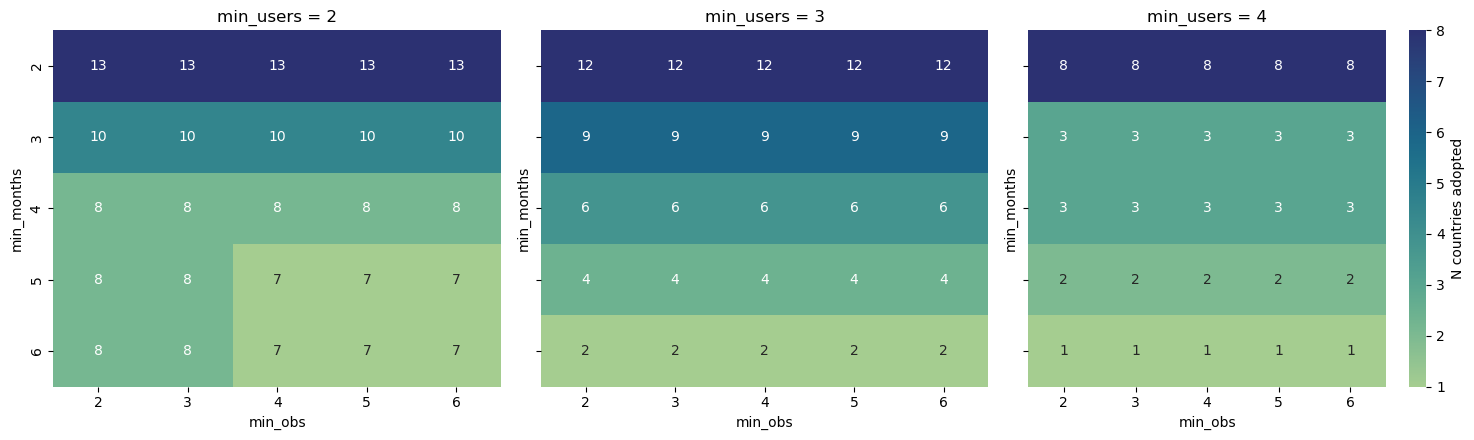

Mean pairwise Spearman rho (onset order): 0.930


In [13]:
df = pd.read_csv("../CWData_Switzerland.csv")
df["created_at_local"] = pd.to_datetime(df["created_at_local"])

summary, onset_matrix = grid_search_sensitivity(df)  # Spaltenname anpassen!

# Facet-Heatmaps: eine pro min_users-Wert
plot_heatmap_facets(summary, min_users_grid=[2, 3, 4])

# rank stability über alle 3D-Kombinationen
corr = rank_stability(onset_matrix)
import numpy as np
mean_rho = np.nanmean(corr.values[np.triu_indices_from(corr, k=1)])
print(f"Mean pairwise Spearman rho (onset order): {mean_rho:.3f}")

In [14]:
df = pd.read_csv("../CWData_Switzerland.csv")
df["date"] = pd.to_datetime(df["date"])

sustained_phases = sustained_adoption(df, min_obs=3, min_months=3, min_users=3)
sustained_phases

C:\Users\yanni\AppData\Local\Temp\ipykernel_43156\2677797811.py:1: DtypeWarning: Columns (0: Plastic_PET, 1: Plastic_POSoft, 2: Plastic_POHard, 3: Plastic_PS, 4: Plastic_PSE, 5: Plastic_PMultilayer, 6: Plastic_POther, 7: Plastic_Removed, 8: Plastic_River_Stagnant, 9: Waterlevel_Physical_Unit, 10: Streamtype, 11: Swimming_Quality, 12: Drinking_Quality, 13: Naturality, 14: StreamColor, 15: Stream_Ground_Visibility, 16: Stream_Animals, 17: Stream_Pollution_Reason, 18: Stream_sometimes_dry, 19: Stream_Name, 20: TempStream_snow_ice, 21: Stream_Waterquality, 22: Stream_Waterclarity, 23: StreamColor_other, 24: Stream_Vegetation, 25: Stream_Foam, 26: Stream_Algae, 27: Stream_Odor, 28: Stream_Odor_Type, 29: Stream_Odor_Type_other, 30: Stream_Litter, 31: Stream_Flow_Alteration, 32: Stream_typical_Color, 33: Stream_Drainage_Basin, 34: Lake_Usage, 35: Lake_Usage_Nr, 36: Lake_Access, 37: Lake_Shore_State, 38: Lake_Swimming, 39: Lake_Transparency, 40: Lake_Color, 41: Lake_Odor, 42: Lake_Shore_Vegeta

,Region,Start_Month,End_Month,Duration_Months
0,Aargau,2020-08-01,2020-12-01,5
1,Aargau,2021-03-01,2021-07-01,5
2,Aargau,2022-08-01,2022-12-01,5
3,Aargau,2023-09-01,2023-11-01,3
4,Aargau,2026-03-01,2026-06-01,4
5,Basel-Landschaft,2019-03-01,2019-05-01,3
6,Bern,2018-06-01,2018-08-01,3
7,Bern,2021-05-01,2021-07-01,3
8,Graubünden,2021-07-01,2021-09-01,3
9,Sankt Gallen,2020-01-01,2020-05-01,5


We also need the monthly observation totals for each canton

In [16]:
df = pd.read_csv("../CWData_Switzerland.csv")

df["year_month"] = pd.to_datetime(df["year_month"]).dt.to_period("M")

monthly_total_obs_per_region = (
    df.groupby(["Region", "year_month"])
      .size()
      .reset_index(name="monthly_obs")
)

monthly_total_obs_per_region.head()

C:\Users\yanni\AppData\Local\Temp\ipykernel_43156\2971714173.py:1: DtypeWarning: Columns (0: Plastic_PET, 1: Plastic_POSoft, 2: Plastic_POHard, 3: Plastic_PS, 4: Plastic_PSE, 5: Plastic_PMultilayer, 6: Plastic_POther, 7: Plastic_Removed, 8: Plastic_River_Stagnant, 9: Waterlevel_Physical_Unit, 10: Streamtype, 11: Swimming_Quality, 12: Drinking_Quality, 13: Naturality, 14: StreamColor, 15: Stream_Ground_Visibility, 16: Stream_Animals, 17: Stream_Pollution_Reason, 18: Stream_sometimes_dry, 19: Stream_Name, 20: TempStream_snow_ice, 21: Stream_Waterquality, 22: Stream_Waterclarity, 23: StreamColor_other, 24: Stream_Vegetation, 25: Stream_Foam, 26: Stream_Algae, 27: Stream_Odor, 28: Stream_Odor_Type, 29: Stream_Odor_Type_other, 30: Stream_Litter, 31: Stream_Flow_Alteration, 32: Stream_typical_Color, 33: Stream_Drainage_Basin, 34: Lake_Usage, 35: Lake_Usage_Nr, 36: Lake_Access, 37: Lake_Shore_State, 38: Lake_Swimming, 39: Lake_Transparency, 40: Lake_Color, 41: Lake_Odor, 42: Lake_Shore_Vegeta

,Region,year_month,monthly_obs
0,Aargau,2017-05,7
1,Aargau,2017-07,2
2,Aargau,2017-09,2
3,Aargau,2017-10,1
4,Aargau,2017-11,1


First and total number of observations and total number of users per canton; same as in Part 1

In [17]:
df = pd.read_csv("../CWData_Switzerland.csv")
df["created_at_local"] = pd.to_datetime(df["created_at_local"])
df["year_month"] = pd.to_datetime(df["year_month"]).dt.to_period("M")

first_regions = (
    df
    .groupby("Region")
    .agg(
        first_date = ("created_at_local","min"),
        total_observations = ("created_at_local","count"),
        unique_users = ("created_by","nunique")
    )
    .reset_index()
)

pd.set_option("display.max_rows", None)

first_regions

C:\Users\yanni\AppData\Local\Temp\ipykernel_43156\2684053785.py:1: DtypeWarning: Columns (0: Plastic_PET, 1: Plastic_POSoft, 2: Plastic_POHard, 3: Plastic_PS, 4: Plastic_PSE, 5: Plastic_PMultilayer, 6: Plastic_POther, 7: Plastic_Removed, 8: Plastic_River_Stagnant, 9: Waterlevel_Physical_Unit, 10: Streamtype, 11: Swimming_Quality, 12: Drinking_Quality, 13: Naturality, 14: StreamColor, 15: Stream_Ground_Visibility, 16: Stream_Animals, 17: Stream_Pollution_Reason, 18: Stream_sometimes_dry, 19: Stream_Name, 20: TempStream_snow_ice, 21: Stream_Waterquality, 22: Stream_Waterclarity, 23: StreamColor_other, 24: Stream_Vegetation, 25: Stream_Foam, 26: Stream_Algae, 27: Stream_Odor, 28: Stream_Odor_Type, 29: Stream_Odor_Type_other, 30: Stream_Litter, 31: Stream_Flow_Alteration, 32: Stream_typical_Color, 33: Stream_Drainage_Basin, 34: Lake_Usage, 35: Lake_Usage_Nr, 36: Lake_Access, 37: Lake_Shore_State, 38: Lake_Swimming, 39: Lake_Transparency, 40: Lake_Color, 41: Lake_Odor, 42: Lake_Shore_Vegeta

,Region,first_date,total_observations,unique_users
0,Aargau,2017-05-09 12:42:43,1198,257
1,Appenzell Ausserrhoden,2026-06-19 18:23:16,2,1
2,Appenzell Innerrhoden,2019-09-14 15:54:37,6,5
3,Basel-Landschaft,2018-08-08 19:18:02,68,22
4,Basel-Stadt,2017-02-11 12:36:29,23,12
5,Bern,2017-05-13 18:58:08,2399,102
6,Fribourg,2020-10-30 18:19:41,69,15
7,Genève,2018-06-03 14:10:06,44,7
8,Glarus,2017-10-21 13:30:09,13,8
9,Graubünden,2017-05-25 10:42:53,310,62


We combine the dataset with the sustained adoption phases, the dataset with the countries' first observation date, total observations, total users and the dataset with the number of observations in each month (in order to calculate the average monthly observation counts in a phase).

In [18]:
# uses first_countries and sustained_phases

first_sustained_combo = pd.merge(first_regions, sustained_phases, how="right")
first_sustained_combo["first_date"] = pd.to_datetime(first_sustained_combo["first_date"])
first_sustained_combo["Start_Month"] = pd.to_datetime(first_sustained_combo["Start_Month"])
first_sustained_combo["End_Month"] = pd.to_datetime(first_sustained_combo["End_Month"])

first_sustained_combo = first_sustained_combo.sort_values(["Region", "Start_Month"])

first_sustained_combo["phase_number"] = (first_sustained_combo.groupby("Region").cumcount() + 1)

first_period = first_sustained_combo["first_date"].dt.to_period("M")
start_period = first_sustained_combo["Start_Month"].dt.to_period("M")
end_period = first_sustained_combo["End_Month"].dt.to_period("M")

prev_end_p = (first_sustained_combo.groupby("Region")["End_Month"].shift(1).dt.to_period("M"))

first_sustained_combo["months_since_previous"] = pd.NA

# first phase: time since very first observation in the region
mask_first = first_sustained_combo["phase_number"] == 1
first_sustained_combo.loc[mask_first, "months_since_previous"] = (
    start_period[mask_first] - first_period[mask_first]
).apply(lambda x: x.n)

# second and later phases: time since end of previous phase
mask_later = first_sustained_combo["phase_number"] > 1
first_sustained_combo.loc[mask_later, "months_since_previous"] = (
    start_period[mask_later] - prev_end_p[mask_later]
).apply(lambda x: x.n)

# compute number of users per month
monthly_total_users_per_region = (
    df.assign(year_month=df["year_month"] if isinstance(df["year_month"].dtype, pd.PeriodDtype) 
              else pd.to_datetime(df["year_month"]).dt.to_period("M"))
    .groupby(["Region", "year_month"])["created_by"]
    .nunique()
    .reset_index(name="monthly_users")
)

# compute average number of monthly observations and average number of monthly users during each phase
avg_obs_values = []
avg_users_values = []

for idx, row in first_sustained_combo.iterrows():
    
    region = row["Region"]
    start = row["Start_Month"].to_period("M")
    end = row["End_Month"].to_period("M")
    duration = row["Duration_Months"]
    
    # observations
    obs_subset = monthly_total_obs_per_region[
        (monthly_total_obs_per_region["Region"] == region) &
        (monthly_total_obs_per_region["year_month"] >= start) &
        (monthly_total_obs_per_region["year_month"] <= end)
    ]
    total_obs = obs_subset["monthly_obs"].sum()
    avg_obs_values.append(round(total_obs / duration, 2) if duration > 0 else 0)
    
    # users
    users_subset = monthly_total_users_per_region[
        (monthly_total_users_per_region["Region"] == region) &
        (monthly_total_users_per_region["year_month"] >= start) &
        (monthly_total_users_per_region["year_month"] <= end)
    ]
    total_users = users_subset["monthly_users"].sum()
    avg_users_values.append(round(total_users / duration, 2) if duration > 0 else 0)

first_sustained_combo["avg_monthly_observations"] = avg_obs_values
first_sustained_combo["avg_monthly_users"] = avg_users_values

first_sustained_combo

,Region,first_date,total_observations,unique_users,Start_Month,End_Month,Duration_Months,phase_number,months_since_previous,avg_monthly_observations,avg_monthly_users
0,Aargau,2017-05-09 12:42:43,1198,257,2020-08-01,2020-12-01,5,1,39,46.60,11.80
1,Aargau,2017-05-09 12:42:43,1198,257,2021-03-01,2021-07-01,5,2,3,30.80,9.00
2,Aargau,2017-05-09 12:42:43,1198,257,2022-08-01,2022-12-01,5,3,13,16.80,11.20
3,Aargau,2017-05-09 12:42:43,1198,257,2023-09-01,2023-11-01,3,4,9,34.00,10.33
4,Aargau,2017-05-09 12:42:43,1198,257,2026-03-01,2026-06-01,4,5,28,57.50,23.50
5,Basel-Landschaft,2018-08-08 19:18:02,68,22,2019-03-01,2019-05-01,3,1,7,15.00,3.33
6,Bern,2017-05-13 18:58:08,2399,102,2018-06-01,2018-08-01,3,1,13,50.67,4.00
7,Bern,2017-05-13 18:58:08,2399,102,2021-05-01,2021-07-01,3,2,33,69.00,5.33
8,Graubünden,2017-05-25 10:42:53,310,62,2021-07-01,2021-09-01,3,1,50,7.67,3.33
9,Sankt Gallen,2017-02-05 14:49:16,738,148,2020-01-01,2020-05-01,5,1,35,24.20,6.60


I now have multiple dataframes with important information about cantons and their adoption of the CrowdWater app.

first_sustained_combo: first observation in a canton and all phases of sustained adoption in the same canton (>= 3 obs/month by >= 3 users for at least 3 months) and the time between phases

first_countries: the total number of observations and number of unique users in each canton

first_regions: the number of users that have each canton as their first canton (i.e. made their first observation in the canton)

top_region: the number of users that have each canton as their top canton (i.e. made the majority of their observation in the canton)

Time-to-Adoption map

In [32]:
# uses first_sustained_combo and first_regions

first_sustained_combo_merged = first_sustained_combo.merge(first_regions, on="Region", how="right")

first_phase = first_sustained_combo_merged[
    (first_sustained_combo_merged["phase_number"] == 1) | 
    (first_sustained_combo_merged["phase_number"].isna())
]

first_phase["ISO_A3"] = first_phase["Region"]

first_phase["time_to_adoption_months"] = ((first_phase["Start_Month"] - first_phase["first_date_x"]) / pd.Timedelta(days=30))

world = gpd.read_file(f"../Borders/swissboundaries3d_2026-01_2056_5728/swissBOUNDARIES3D_1_5_TLM_KANTONSGEBIET.shp", engine="fiona").to_crs("EPSG:2056")
world = world.rename(columns={"NAME": "Region"})

CANTON_NAME_FIXES = {
    "St. Gallen": "Sankt Gallen",
    "Luzern": "Lucerne",
}
world["Region"] = world["Region"].replace(CANTON_NAME_FIXES)

map_df = world.merge(first_phase, left_on="Region", right_on="Region", how="left")

conditions = [
    map_df["time_to_adoption_months"].notna(),                 # sustained adoption
    map_df["total_observations_y"].notna(),                    # observations but no adoption
]

choices = [
    "adoption",
    "observations_only"
]

map_df["status"] = np.select(conditions, choices, default="no_observations")

map_df["adoption_class"] = pd.cut(
    map_df["time_to_adoption_months"],
    bins=[-1, 1, 12, 24, 48, 1000],
    labels=[
        "0-1 months",
        "≤ 1 year",
        "≤ 2 years",
        "≤ 4 years",
        "> 4 years"
    ]
)

# colors for adoption classes
blues = plt.cm.Blues_r
adoption_colors = {
    "0-1 months": "#08306b",
    "≤ 1 year": "#08519c",
    "≤ 2 years": "#3182bd",
    "≤ 4 years": "#6baed6",
    "> 4 years": "#9ecae1",
}

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# no observations
map_df[map_df["status"] == "no_observations"].plot(
    ax=ax, color="grey", edgecolor="black", linewidth=0.5
)

# observations but no adoption
map_df[map_df["status"] == "observations_only"].plot(
    ax=ax, color="#D9A6B3", edgecolor="black", linewidth=0.5
)

# adoption
for label, color in adoption_colors.items():
    subset = map_df[
        (map_df["status"] == "adoption") & 
        (map_df["adoption_class"] == label)
    ]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.5)

# manual legend
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=label)
    for label, color in adoption_colors.items()
] + [
    mpatches.Patch(facecolor="#D9A6B3", edgecolor="black", linewidth=0.5, label="No sustained adoption"),
    mpatches.Patch(facecolor="grey", edgecolor="black", linewidth=0.5, label="No observations"),
]

ax.legend(handles=legend_handles, loc="upper left", title="Time", title_fontsize=15, fontsize=12)
ax.axis("off")
plt.title("Time until Sustained Adoption", fontsize=18)
plt.savefig("../Products/Switzerland/Time_to_Sustained_Adoption_Switzerland.png", dpi=300, bbox_inches="tight")
plt.close()

C:\Users\yanni\AppData\Local\Temp\ipykernel_43156\4293216903.py:62: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  map_df[map_df["status"] == "no_observations"].plot(


Adoption Intensity Map (average of all phases)

In [27]:
def weighted_avg(group, value_col, weight_col="Duration_Months"):
    return (group[value_col] * group[weight_col]).sum() / group[weight_col].sum()

adoption_intensity = (
    first_sustained_combo
    .groupby("Region")
    .apply(lambda g: pd.Series({
        "avg_monthly_observations": weighted_avg(g, "avg_monthly_observations"),
        "avg_monthly_users": weighted_avg(g, "avg_monthly_users"),
        "total_sustained_months": g["Duration_Months"].sum(),
    }))
    .reset_index()
)

adoption_intensity["obs_per_user"] = (
    adoption_intensity["avg_monthly_observations"] / adoption_intensity["avg_monthly_users"]
)

adoption_intensity

,Region,avg_monthly_observations,avg_monthly_users,total_sustained_months,obs_per_user
0,Aargau,36.500,12.954091,22.0,2.817643
1,Basel-Landschaft,15.000,3.330000,3.0,4.504505
2,Bern,59.835,4.665000,6.0,12.826367
3,Graubünden,7.670,3.330000,3.0,2.303303
4,Sankt Gallen,14.555,5.498889,18.0,2.646898
5,Schwyz,10.000,3.600000,5.0,2.777778
6,Ticino,58.000,3.750000,4.0,15.466667
7,Vaud,23.250,3.250000,4.0,7.153846
8,Zürich,127.910,19.191759,108.0,6.664840


In [34]:
# uses adoption_intensity

world_area = gpd.read_file(f"../Borders/swissboundaries3d_2026-01_2056_5728/swissBOUNDARIES3D_1_5_TLM_KANTONSGEBIET.shp", engine="fiona").to_crs("EPSG:2056")
world_area = world_area.rename(columns={"NAME": "Region"})
world_area["area_km2"] = world_area.geometry.area / 1e6

CANTON_NAME_FIXES = {
    "St. Gallen": "Sankt Gallen",
    "Luzern": "Lucerne",
}
world_area["Region"] = world_area["Region"].replace(CANTON_NAME_FIXES)


area_lookup = world_area[["Region", "area_km2"]]

index_df = adoption_intensity.merge(area_lookup, on="Region", how="left")

index_df["obs_density"] = index_df["avg_monthly_observations"] / index_df["area_km2"]
index_df["user_density"] = index_df["avg_monthly_users"] / index_df["area_km2"]


def minmax_norm(s):
    return (s - s.min()) / (s.max() - s.min())

index_df["obs_density_norm"] = minmax_norm(index_df["obs_density"])
index_df["user_density_norm"] = minmax_norm(index_df["user_density"])

index_df["activity_norm"] = (index_df["obs_density_norm"] + index_df["user_density_norm"]) / 2
index_df["duration_norm"] = minmax_norm(index_df["total_sustained_months"])

index_df["adoption_intensity_index"] = (
    0.5 * index_df["activity_norm"] +
    0.5 * index_df["duration_norm"]
)

index_df

,Region,avg_monthly_observations,avg_monthly_users,total_sustained_months,obs_per_user,area_km2,obs_density,user_density,obs_density_norm,user_density_norm,activity_norm,duration_norm,adoption_intensity_index
0,Aargau,36.500,12.954091,22.0,2.817643,1403.798008,0.026001,0.009228,0.341847,0.823884,0.582865,0.180952,0.381909
1,Basel-Landschaft,15.000,3.330000,3.0,4.504505,517.668761,0.028976,0.006433,0.382658,0.560970,0.471814,0.000000,0.235907
2,Bern,59.835,4.665000,6.0,12.826367,5938.892525,0.010075,0.000785,0.123393,0.029801,0.076597,0.028571,0.052584
3,Graubünden,7.670,3.330000,3.0,2.303303,7105.296294,0.001079,0.000469,0.000000,0.000000,0.000000,0.000000,0.000000
4,Sankt Gallen,14.555,5.498889,18.0,2.646898,2028.199748,0.007176,0.002711,0.083630,0.210932,0.147281,0.142857,0.145069
5,Schwyz,10.000,3.600000,5.0,2.777778,907.882288,0.011015,0.003965,0.136281,0.328887,0.232584,0.019048,0.125816
6,Ticino,58.000,3.750000,4.0,15.466667,2812.154294,0.020625,0.001333,0.268103,0.081345,0.174724,0.009524,0.092124
7,Vaud,23.250,3.250000,4.0,7.153846,3212.022111,0.007238,0.001012,0.084482,0.051089,0.067786,0.009524,0.038655
8,Zürich,127.910,19.191759,108.0,6.664840,1728.941726,0.073982,0.011100,1.000000,1.000000,1.000000,1.000000,1.000000


In [39]:
# uses index_df and first_regions (for the "observations but no adoption" / "no observations" layers)

map_source = index_df.merge(first_regions, on="Region", how="right")

world = gpd.read_file(f"../Borders/swissboundaries3d_2026-01_2056_5728/swissBOUNDARIES3D_1_5_TLM_KANTONSGEBIET.shp", engine="fiona").to_crs("EPSG:2056")
world = world.rename(columns={"NAME": "Region"})

CANTON_NAME_FIXES = {
    "St. Gallen": "Sankt Gallen",
    "Luzern": "Lucerne",
}
world["Region"] = world["Region"].replace(CANTON_NAME_FIXES)

map_df = world.merge(map_source, on="Region", how="left")

conditions = [
    map_df["adoption_intensity_index"].notna(),   # sustained adoption
    map_df["total_observations"].notna(),          # observations but no sustained adoption
]

choices = [
    "adoption",
    "observations_only"
]

map_df["status"] = np.select(conditions, choices, default="no_observations")

# unregelmäßige Bins, angepasst an die tatsächliche Verteilung (CH als Ausreißer bei 1.0)
bins = [0, 0.05, 0.1, 0.2, 0.5, 1.01]
labels = ["Very low", "Low", "Moderate", "High", "Very high"]

map_df["intensity_class"] = pd.cut(
    map_df["adoption_intensity_index"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

intensity_colors = {
    "Very low": "#c6dbef",
    "Low": "#6baed6",
    "Moderate": "#3182bd",
    "High": "#08519c",
    "Very high": "#08306b",
}

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

map_df[map_df["status"] == "no_observations"].plot(
    ax=ax, color="grey", edgecolor="black", linewidth=0.5
)

map_df[map_df["status"] == "observations_only"].plot(
    ax=ax, color="#D9A6B3", edgecolor="black", linewidth=0.5
)

for label, color in intensity_colors.items():
    subset = map_df[
        (map_df["status"] == "adoption") &
        (map_df["intensity_class"] == label)
    ]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.5)

legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=label)
    for label, color in intensity_colors.items()
] + [
    mpatches.Patch(facecolor="#D9A6B3", edgecolor="black", linewidth=0.5, label="No sustained adoption"),
    mpatches.Patch(facecolor="grey", edgecolor="black", linewidth=0.5, label="No observations"),
]

ax.legend(handles=legend_handles, loc="lower left", title="Adoption Intensity Index", title_fontsize=15, fontsize=12)
ax.axis("off")
plt.title("Composite Adoption Intensity Index (Activity + Duration, Normalized by Area)", fontsize=18)
plt.savefig("../Products/Switzerland/Switzerland_Adoption_Intensity_Index.png", dpi=300, bbox_inches="tight")
plt.close()

C:\Users\yanni\AppData\Local\Temp\ipykernel_43156\3841487708.py:49: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  map_df[map_df["status"] == "no_observations"].plot(


Graphic that shows all adopting cantons and their adoption phases

In [42]:
world_area = gpd.read_file(f"../Borders/swissboundaries3d_2026-01_2056_5728/swissBOUNDARIES3D_1_5_TLM_KANTONSGEBIET.shp", engine="fiona").to_crs("EPSG:2056")
world_area = world_area.rename(columns={"NAME": "Region"})

CANTON_NAME_FIXES = {
    "St. Gallen": "Sankt Gallen",
    "Luzern": "Lucerne",
}
world_area["Region"] = world_area["Region"].replace(CANTON_NAME_FIXES)
world_area["area_km2"] = world_area.geometry.area / 1e6
area_lookup = world_area[["Region", "area_km2"]]

gantt_df = first_sustained_combo.copy()
gantt_df["Region"] = gantt_df["Region"]
gantt_df = gantt_df.merge(area_lookup, on="Region", how="left")

gantt_df["obs_density"] = gantt_df["avg_monthly_observations"] / gantt_df["area_km2"] * 1000
gantt_df["user_density"] = gantt_df["avg_monthly_users"] / gantt_df["area_km2"] * 1000

def minmax_norm(s):
    return (s - s.min()) / (s.max() - s.min())

gantt_df["obs_density_norm"] = minmax_norm(gantt_df["obs_density"])
gantt_df["user_density_norm"] = minmax_norm(gantt_df["user_density"])
gantt_df["activity_norm"] = (gantt_df["obs_density_norm"] + gantt_df["user_density_norm"]) / 2


bins = [0, 0.05, 0.1, 0.2, 0.5, 1.01]
labels = ["Very low", "Low", "Moderate", "High", "Very high"]

gantt_df["intensity_class"] = pd.cut(gantt_df["activity_norm"], bins=bins, labels=labels, include_lowest=True)

intensity_colors = {
    "Very low": "#c6dbef",
    "Low": "#6baed6",
    "Moderate": "#3182bd",
    "High": "#08519c",
    "Very high": "#08306b",
}

region_order = (
    first_sustained_combo.groupby("Region")["Start_Month"]
    .min()
    .sort_values()
    .index.tolist()
)


fig, ax = plt.subplots(figsize=(12, 0.5 * len(region_order) + 1))

for i, region in enumerate(region_order):
    phases = gantt_df[gantt_df["Region"] == region]
    for _, row in phases.iterrows():
        start = mdates.date2num(row["Start_Month"])
        end = mdates.date2num(row["End_Month"])
        color = intensity_colors[row["intensity_class"]]
        ax.broken_barh(
            [(start, end - start)],
            (i - 0.4, 0.8),
            facecolors=color,
            edgecolor="black",
            linewidth=0.5
        )

legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=label)
    for label, color in intensity_colors.items()
]
ax.legend(handles=legend_handles, loc="lower left", title="Activity Index", fontsize=11, title_fontsize=13)

ax.set_yticks(range(len(region_order)))
ax.set_yticklabels(region_order, fontsize=12)
ax.xaxis_date()
ax.tick_params(axis="x", labelsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Year", fontsize=17)
ax.set_ylabel("Region", fontsize=17)
ax.set_title("Sustained Adoption Phases by Region", fontsize=20)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../Products/Switzerland/Switzerland_Adoption_Phases_Graphic.png", dpi=300, bbox_inches="tight")
plt.close()